In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix

## Load and Prepare Data

In [2]:
df = pd.read_csv('cleaned_spotify.csv')

df = df.dropna()

if df['explicit'].dtype == object:
    df['explicit'] = df['explicit'].astype(str).str.lower().map({'true': 1, 'false': 0})
else:
    df['explicit'] = df['explicit'].astype(int)

features = [
    'danceability', 'energy', 'loudness', 'speechiness', 
    'acousticness', 'instrumentalness', 'liveness', 
    'valence', 'tempo', 'duration_min', 'explicit'
]

X = df[features]
y = df['popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model 1: Random Forest Regressor

In [4]:
print("\n--- Training Random Forest Regressor ---")
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_scaled, y_train)

y_pred_rf = rf_reg.predict(X_test_scaled)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"Random Forest R^2:  {rf_r2:.4f}")


--- Training Random Forest Regressor ---
Random Forest RMSE: 19.69
Random Forest R^2:  0.2191


### Visualization: Feature Importance

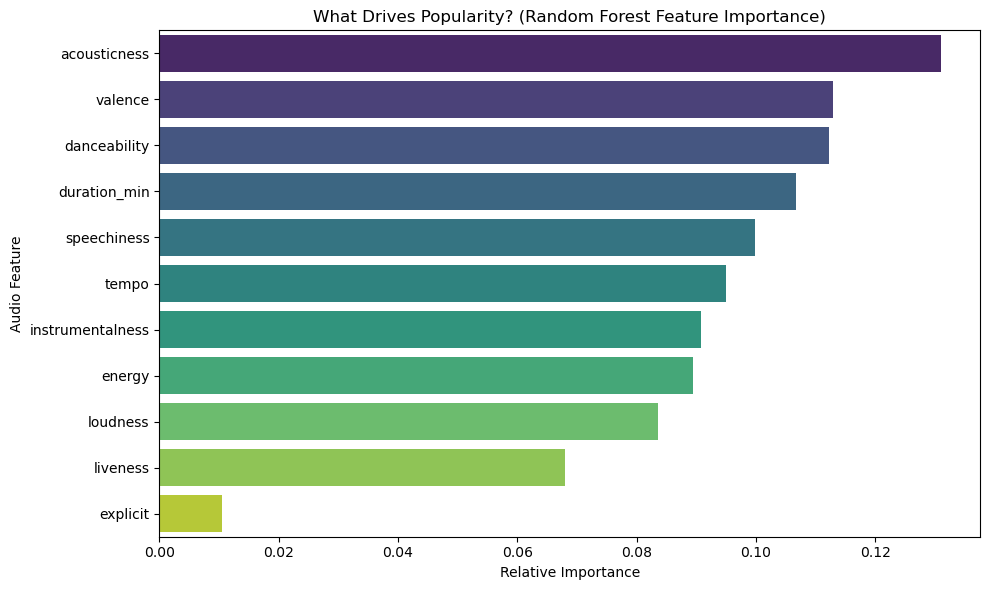

In [5]:
importances = rf_reg.feature_importances_
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('What Drives Popularity? (Random Forest Feature Importance)')
plt.xlabel('Relative Importance')
plt.ylabel('Audio Feature')
plt.tight_layout()
plt.show()

## Classification 1: Predicting a "Hit" (Popularity >= 70)

Hit Prediction Accuracy: 0.5755296421577355
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.57      0.72     21422
           1       0.08      0.75      0.14      1046

    accuracy                           0.58     22468
   macro avg       0.53      0.66      0.43     22468
weighted avg       0.94      0.58      0.69     22468



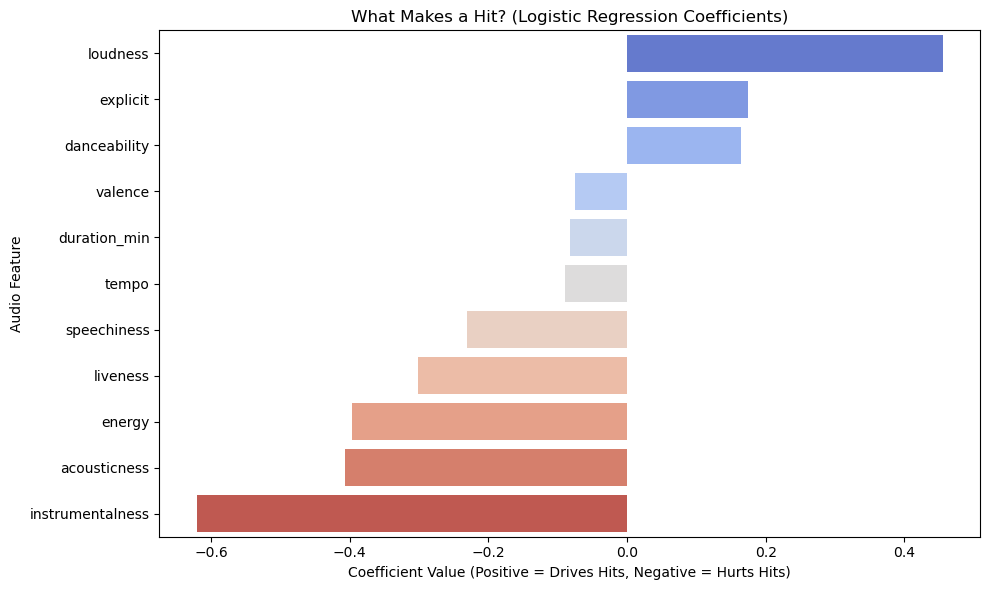

In [9]:
df['is_hit'] = (df['popularity'] >= 70).astype(int)
y_hit = df['is_hit']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X, y_hit, test_size=0.2, random_state=42)

log_hit = LogisticRegression(class_weight='balanced', random_state=42)
log_hit.fit(X_train_scaled, y_train_h)
y_pred_h = log_hit.predict(X_test_scaled)

print("Hit Prediction Accuracy:", accuracy_score(y_test_h, y_pred_h))
print("Classification Report:\n", classification_report(y_test_h, y_pred_h))

plt.figure(figsize=(10, 6))
hit_importance_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': log_hit.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

sns.barplot(x='Coefficient', y='Feature', data=hit_importance_df, hue='Feature', palette='coolwarm', legend=False)
plt.title('What Makes a Hit? (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value (Positive = Drives Hits, Negative = Hurts Hits)')
plt.ylabel('Audio Feature')
plt.tight_layout()
plt.show()

## Classification 2: Predicting 'Explicit' Status

Explicit Prediction Accuracy: 0.8053676339683105
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.81      0.88     20543
           1       0.27      0.76      0.40      1925

    accuracy                           0.81     22468
   macro avg       0.62      0.79      0.64     22468
weighted avg       0.91      0.81      0.84     22468



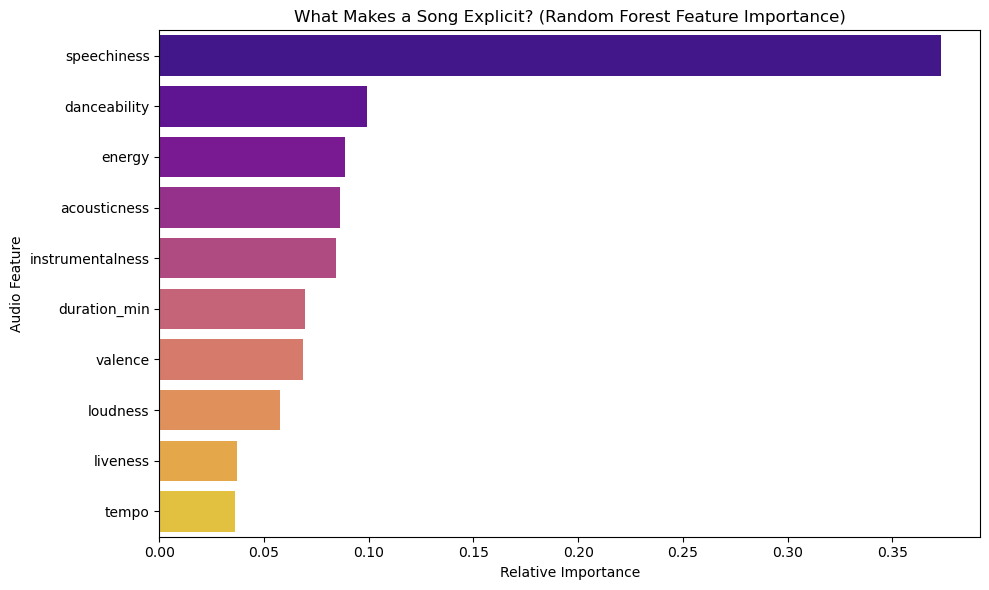

In [10]:
features_ex = [f for f in features if f != 'explicit']
X_ex = df[features_ex]
y_ex = df['explicit']

X_train_ex, X_test_ex, y_train_ex, y_test_ex = train_test_split(X_ex, y_ex, test_size=0.2, random_state=42, stratify=y_ex)

scaler_ex = StandardScaler()
X_train_ex_scaled = scaler_ex.fit_transform(X_train_ex)
X_test_ex_scaled = scaler_ex.transform(X_test_ex)

rf_ex = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf_ex.fit(X_train_ex_scaled, y_train_ex)
y_pred_ex = rf_ex.predict(X_test_ex_scaled)

print("Explicit Prediction Accuracy:", accuracy_score(y_test_ex, y_pred_ex))
print("Classification Report:\n", classification_report(y_test_ex, y_pred_ex))

plt.figure(figsize=(10, 6))
ex_importance_df = pd.DataFrame({
    'Feature': features_ex,
    'Importance': rf_ex.feature_importances_
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=ex_importance_df, hue='Feature', palette='plasma', legend=False)
plt.title('What Makes a Song Explicit? (Random Forest Feature Importance)')
plt.xlabel('Relative Importance')
plt.ylabel('Audio Feature')
plt.tight_layout()
plt.show()

## Classification 3: Predicting Genre (Top 5 Genres)

Genre Prediction Accuracy: 0.772
Classification Report:
               precision    recall  f1-score   support

     country       0.77      0.69      0.72       200
       house       0.75      0.87      0.81       200
    mandopop       0.75      0.76      0.75       200
      pagode       0.89      0.87      0.88       200
        rock       0.71      0.68      0.69       200

    accuracy                           0.77      1000
   macro avg       0.77      0.77      0.77      1000
weighted avg       0.77      0.77      0.77      1000



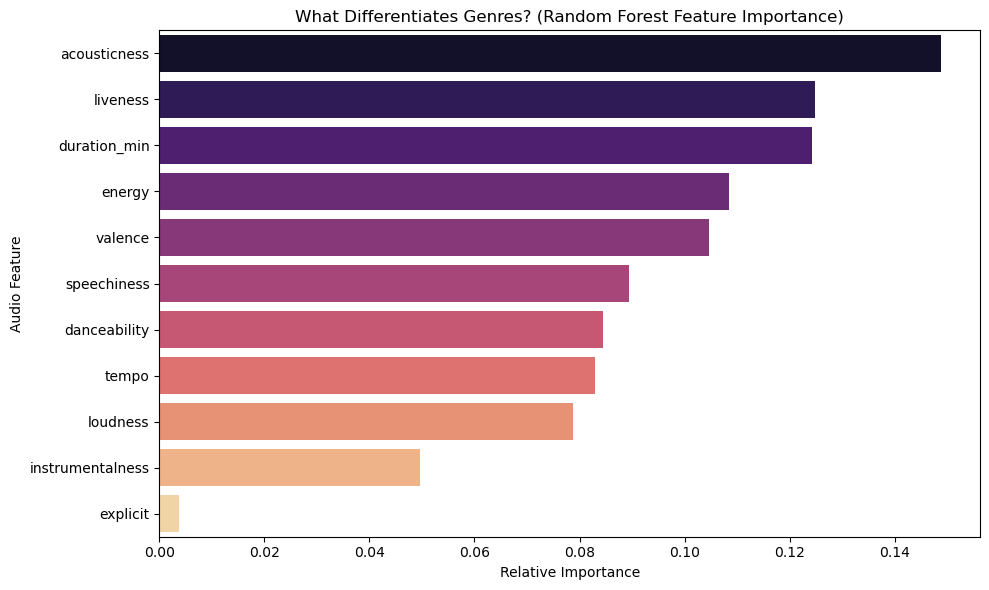

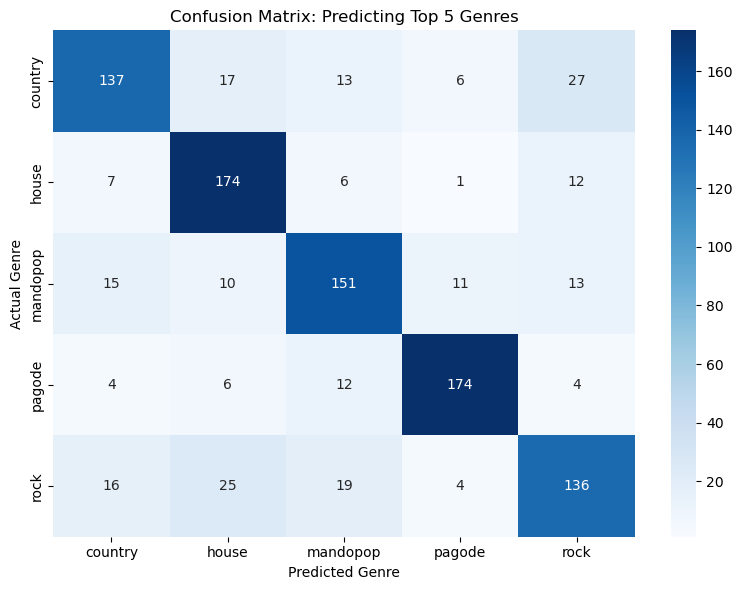

In [11]:
top_5_genres = df['track_genre'].value_counts().nlargest(5).index
df_genre = df[df['track_genre'].isin(top_5_genres)]
    
X_g = df_genre[features]
y_g = df_genre['track_genre']
    
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(X_g, y_g, test_size=0.2, random_state=42, stratify=y_g)
    
scaler_g = StandardScaler()
X_train_g_scaled = scaler_g.fit_transform(X_train_g)
X_test_g_scaled = scaler_g.transform(X_test_g)
    
rf_g = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_g.fit(X_train_g_scaled, y_train_g)
y_pred_g = rf_g.predict(X_test_g_scaled)
    
print("Genre Prediction Accuracy:", accuracy_score(y_test_g, y_pred_g))
print("Classification Report:\n", classification_report(y_test_g, y_pred_g))

plt.figure(figsize=(10, 6))
genre_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_g.feature_importances_
}).sort_values(by='Importance', ascending=False)
    
sns.barplot(x='Importance', y='Feature', data=genre_importance_df, hue='Feature', palette='magma', legend=False)
plt.title('What Differentiates Genres? (Random Forest Feature Importance)')
plt.xlabel('Relative Importance')
plt.ylabel('Audio Feature')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_g, y_pred_g)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=rf_g.classes_, yticklabels=rf_g.classes_)
plt.title('Confusion Matrix: Predicting Top 5 Genres')
plt.xlabel('Predicted Genre')
plt.ylabel('Actual Genre')
plt.tight_layout()
plt.show()